In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


In [3]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
df.head(100)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,15,female,1.8,Instagram,6.4,2.4,2.16,1.9,medium,3,6,9,0
96,13,male,3.1,TikTok,5.4,1.9,3.66,0.4,low,7,4,2,0
97,13,female,3.5,TikTok,5.2,2.5,2.57,1.1,high,1,6,3,0
98,18,male,7.4,TikTok,6.4,2.2,3.51,1.0,high,4,5,4,0


In [4]:
df.shape

(1200, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [6]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [7]:
categorical_col = df.select_dtypes(include='object')
numerical_col = df.select_dtypes(exclude='object')
for col in categorical_col:
    print(categorical_col[col].value_counts())
    print("------------\n----------")


gender
male      615
female    585
Name: count, dtype: int64
------------
----------
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64
------------
----------
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64
------------
----------


In [8]:
for col in numerical_col:
    print(numerical_col[col].value_counts())
    print("------------\n----------")

age
13    200
15    180
18    172
17    170
16    163
19    162
14    153
Name: count, dtype: int64
------------
----------
daily_social_media_hours
3.5    28
4.0    26
3.8    25
7.4    24
7.2    24
       ..
3.7    11
1.9    10
6.7    10
4.9     8
1.0     4
Name: count, Length: 71, dtype: int64
------------
----------
sleep_hours
7.4    34
6.8    34
5.7    33
8.0    32
4.4    32
5.3    31
8.6    31
5.1    30
4.2    29
6.7    29
6.4    28
6.3    28
7.5    28
4.1    27
8.2    26
4.3    26
7.1    26
7.0    25
4.7    25
8.4    25
4.5    25
6.5    24
7.3    24
7.2    24
5.0    24
5.8    24
8.7    23
4.9    23
4.6    23
7.8    23
8.8    22
6.1    22
5.4    22
6.9    22
8.9    21
6.0    21
5.6    21
4.8    20
7.6    20
5.2    20
7.9    19
8.5    19
5.5    18
7.7    18
6.6    18
5.9    17
8.1    17
6.2    15
8.3    12
9.0    10
4.0    10
Name: count, dtype: int64
------------
----------
screen_time_before_sleep
1.4    67
1.9    56
0.9    53
0.7    53
2.5    53
2.0    53
1.5    52
2.1    50
2.

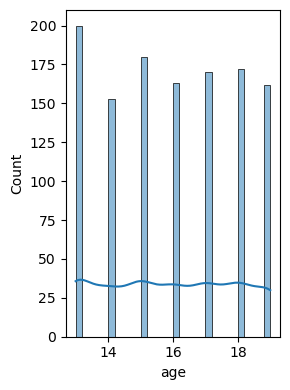

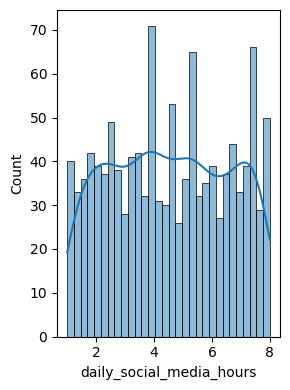

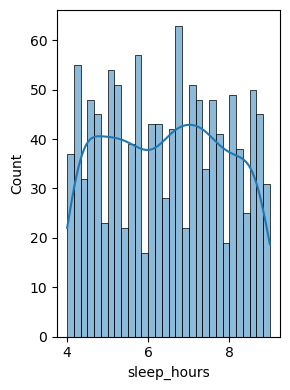

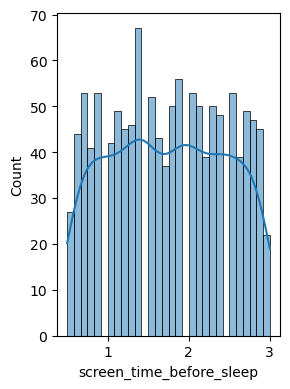

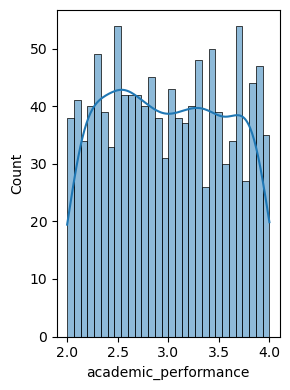

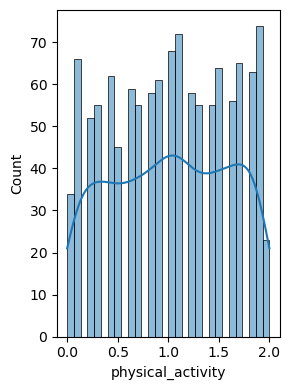

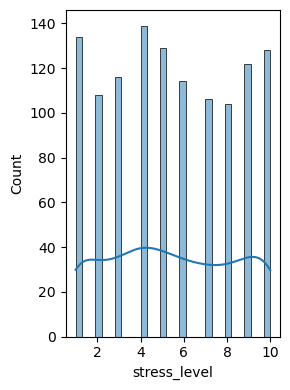

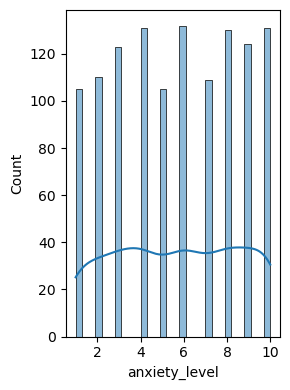

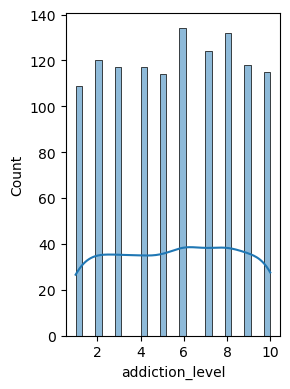

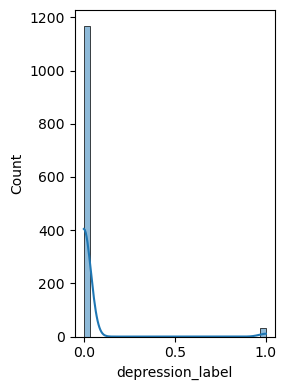

In [9]:
for col in numerical_col:
    plt.figure(figsize=(3,4))
    sns.histplot(numerical_col[col],bins=30,kde=True)
    plt.tight_layout()
    plt.show()


In [10]:
df = pd.get_dummies(df, columns=['gender','platform_usage','social_interaction_level'], drop_first=False, dtype=int)
df.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_high,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0,0,1,0,1,0,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,1,0,0,0,1,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,1,0,1,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0,0,1,0,0,1,0,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,1,0,1,0,0,0,0,1


In [11]:
X = df.drop(['depression_label'],axis=1)
y=df['depression_label']

In [12]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
df.columns


Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label',
       'gender_female', 'gender_male', 'platform_usage_Both',
       'platform_usage_Instagram', 'platform_usage_TikTok',
       'social_interaction_level_high', 'social_interaction_level_low',
       'social_interaction_level_medium'],
      dtype='object')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


models = {
    "Logistic Regression": LogisticRegressionCV(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "adaboost":AdaBoostClassifier(),
    "xgbc":XGBClassifier()

}

results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    results_list.append(metrics)


results_df = pd.DataFrame(results_list)
print(results_df.sort_values(by="F1-Score", ascending=False))

best_model =XGBClassifier(random_state=42)
best_model.fit(X_train,y_train)


                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
2    Gradient Boosting  0.995833        1.0  0.833333  0.909091  0.989316
3             adaboost  0.995833        1.0  0.833333  0.909091  0.978276
4                 xgbc  0.995833        1.0  0.833333  0.909091  0.998575
0  Logistic Regression  0.987500        1.0  0.500000  0.666667  0.989316
1        Random Forest  0.979167        1.0  0.166667  0.285714  0.997151
